# Storm-Level Missing Wind Data Analysis
This notebook analyzes the completeness of the `max_wind_kt` (maximum wind speed) feature on a per-storm basis. Specifically, we want to find out how many storms have less than 15% missing wind data across different time periods.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('../../Datasets/data.csv', low_memory=False)
df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year


## Aggregate by Storm
We group the rows by `international_id` to compute the total number of records per storm and how many of those records are missing the wind feature.

In [22]:
# Group by storm (international_id)
storms = df.groupby('international_id').agg(
    start_year=('time', lambda x: x.dt.year.min()),
    total_lines=('max_wind_kt', 'size'),
    missing_wind=('max_wind_kt', lambda x: x.isna().sum())
).reset_index()

# Calculate the percentage of missing wind data for each storm
storms['missing_pct'] = storms['missing_wind'] / storms['total_lines']

storms.head()

,international_id,start_year,total_lines,missing_wind,missing_pct
0,1,2000,53,0,0.0
1,2,2000,31,0,0.0
2,3,2000,40,0,0.0
3,4,2000,37,0,0.0
4,5,2000,28,0,0.0


## Results by Time Period
Now we calculate how many storms are missing < 15% of their wind feature, and their percentage relative to all storms in the period.

In [23]:
periods = [
    ('Overall', 0),
    ('1977-present', 1977),
    ('1980-present', 1980),
    ('1990-present', 1990)
]

for name, start_yr in periods:
    period_storms = storms[storms['start_year'] >= start_yr]
    total_storms = len(period_storms)
    valid_storms = len(period_storms[period_storms['missing_pct'] < 0.15])
    
    pct = (valid_storms / total_storms * 100) if total_storms > 0 else 0
    
    print(f'=== {name} ===')
    print(f'Total storms: {total_storms}')
    print(f'Storms with <15% missing wind data: {valid_storms}')
    print(f'Percentage: {pct:.2f}%\n')

=== Overall ===
Total storms: 1955
Storms with <15% missing wind data: 1248
Percentage: 63.84%

=== 1977-present ===
Total storms: 1248
Storms with <15% missing wind data: 1248
Percentage: 100.00%

=== 1980-present ===
Total storms: 1173
Storms with <15% missing wind data: 1173
Percentage: 100.00%

=== 1990-present ===
Total storms: 903
Storms with <15% missing wind data: 903
Percentage: 100.00%



## Missing Features by Storm Grade
Here we rank the storm grades by their percentage of missing features per record (from most missing to least missing) across the different time periods.
We are specifically analyzing the completeness of the following detailed subset of features:
`max_wind_kt`, `dir_50kt`, `dir_50kt_name`, `rad_50kt_long_nm`, `rad_50kt_short_nm`, `dir_30kt`, `dir_30kt_name`, `rad_30kt_long_nm`, `rad_30kt_short_nm`, `landfall_flag`, `flag_last`, `time_diff_hours`, `revision_date`.

In [24]:
target_features = [
    "max_wind_kt",
    "dir_50kt", "dir_50kt_name", "rad_50kt_long_nm", "rad_50kt_short_nm",
    "dir_30kt", "dir_30kt_name", "rad_30kt_long_nm", "rad_30kt_short_nm",
    "landfall_flag", "flag_last", "time_diff_hours", "revision_date"
]

for name, start_yr in periods:
    period_data = df[df['year'] >= start_yr].copy()
    
    # Calculate the percentage of missing values per row specifically for target_features
    period_data['missing_pct'] = period_data[target_features].isnull().mean(axis=1)
    
    # Group by grade_name and calculate the average missing percentage
    grade_missing = period_data.groupby('grade_name')['missing_pct'].mean().reset_index()
    
    if not grade_missing.empty:
        print(f'=== {name} Ranking ===')
        ranked = grade_missing.sort_values('missing_pct', ascending=False)
        for i, row in ranked.iterrows():
            print(f"{row['grade_name']}: {row['missing_pct']*100:.2f}% missing")
        print("\n")


=== Overall Ranking ===
TC of TS intensity or higher: 76.92% missing
Tropical Depression (TD): 72.31% missing
Extra-tropical Cyclone (L): 72.05% missing
Entering RSMC area: 34.73% missing
Tropical Storm (TS): 7.64% missing
Typhoon (TY): 7.62% missing
Severe Tropical Storm (STS): 7.60% missing


=== 1977-present Ranking ===
Extra-tropical Cyclone (L): 69.23% missing
Tropical Depression (TD): 69.23% missing
Entering RSMC area: 28.91% missing
Tropical Storm (TS): 7.64% missing
Typhoon (TY): 7.62% missing
Severe Tropical Storm (STS): 7.60% missing


=== 1980-present Ranking ===
Extra-tropical Cyclone (L): 69.23% missing
Tropical Depression (TD): 69.23% missing
Entering RSMC area: 28.91% missing
Tropical Storm (TS): 7.64% missing
Typhoon (TY): 7.62% missing
Severe Tropical Storm (STS): 7.60% missing


=== 1990-present Ranking ===
Extra-tropical Cyclone (L): 69.23% missing
Tropical Depression (TD): 69.23% missing
Entering RSMC area: 25.64% missing
Tropical Storm (TS): 7.62% missing
Typhoon (

## Missing 30-knot and 50-knot Wind Radii by Grade
This section ranks storm grades based strictly on how often they are missing the 30-knot and 50-knot wind speed/direction features. This illustrates exactly why weaker/non-tropical systems rank highly for missing data.

In [25]:
wind_radii_features = [
    "dir_50kt", "dir_50kt_name", "rad_50kt_long_nm", "rad_50kt_short_nm",
    "dir_30kt", "dir_30kt_name", "rad_30kt_long_nm", "rad_30kt_short_nm"
]

for name, start_yr in periods:
    period_data = df[df['year'] >= start_yr].copy()
    
    period_data['missing_pct'] = period_data[wind_radii_features].isnull().mean(axis=1)
    grade_missing = period_data.groupby('grade_name')['missing_pct'].mean().reset_index()
    
    if not grade_missing.empty:
        print(f'=== {name} Ranking (Wind Radii Only) ===')
        ranked = grade_missing.sort_values('missing_pct', ascending=False)
        for i, row in ranked.iterrows():
            print(f"{row['grade_name']}: {row['missing_pct']*100:.2f}% missing")
        print("\n")


=== Overall Ranking (Wind Radii Only) ===
Extra-tropical Cyclone (L): 100.00% missing
Tropical Depression (TD): 100.00% missing
TC of TS intensity or higher: 100.00% missing
Entering RSMC area: 42.42% missing
Severe Tropical Storm (STS): 0.00% missing
Tropical Storm (TS): 0.00% missing
Typhoon (TY): 0.00% missing


=== 1977-present Ranking (Wind Radii Only) ===
Extra-tropical Cyclone (L): 100.00% missing
Tropical Depression (TD): 100.00% missing
Entering RSMC area: 34.48% missing
Severe Tropical Storm (STS): 0.00% missing
Tropical Storm (TS): 0.00% missing
Typhoon (TY): 0.00% missing


=== 1980-present Ranking (Wind Radii Only) ===
Extra-tropical Cyclone (L): 100.00% missing
Tropical Depression (TD): 100.00% missing
Entering RSMC area: 34.48% missing
Severe Tropical Storm (STS): 0.00% missing
Tropical Storm (TS): 0.00% missing
Typhoon (TY): 0.00% missing


=== 1990-present Ranking (Wind Radii Only) ===
Extra-tropical Cyclone (L): 100.00% missing
Tropical Depression (TD): 100.00% missin

## Storm Grade Progression
Let's pick a random storm from the dataset and observe how its `grade_name` evolves chronologically over its lifespan.

In [26]:
# Pick a random storm (using a set random seed for reproducibility in output, or omit for truly random)
random_storm_id = np.random.choice(df['international_id'].dropna().unique())
storm_data = df[df['international_id'] == random_storm_id].sort_values('time')

storm_name = storm_data['name'].iloc[0]
print(f"Random Storm ID: {random_storm_id} (Name: {storm_name})")
print("Grade progression over time (showing points of transition):")

grade_progression = storm_data[['time', 'grade_name']].dropna()
previous_grade = None

for _, row in grade_progression.iterrows():
    current_grade = row['grade_name']
    if current_grade != previous_grade:
        print(f"  {row['time']} -> {current_grade}")
        previous_grade = current_grade


Random Storm ID: 911 (Name: KROVANH)
Grade progression over time (showing points of transition):
  2009-08-28 00:00:00 -> Tropical Depression (TD)
  2009-08-28 12:00:00 -> Tropical Storm (TS)
  2009-08-29 18:00:00 -> Severe Tropical Storm (STS)
  2009-08-31 21:00:00 -> Tropical Storm (TS)
  2009-09-01 12:00:00 -> Extra-tropical Cyclone (L)


## Extra-tropical Cyclone Analysis
Let's plot the geographical positions of all storms when they are in the `Extra-tropical Cyclone (L)` state, mapped onto the entire region of the Western North Pacific.

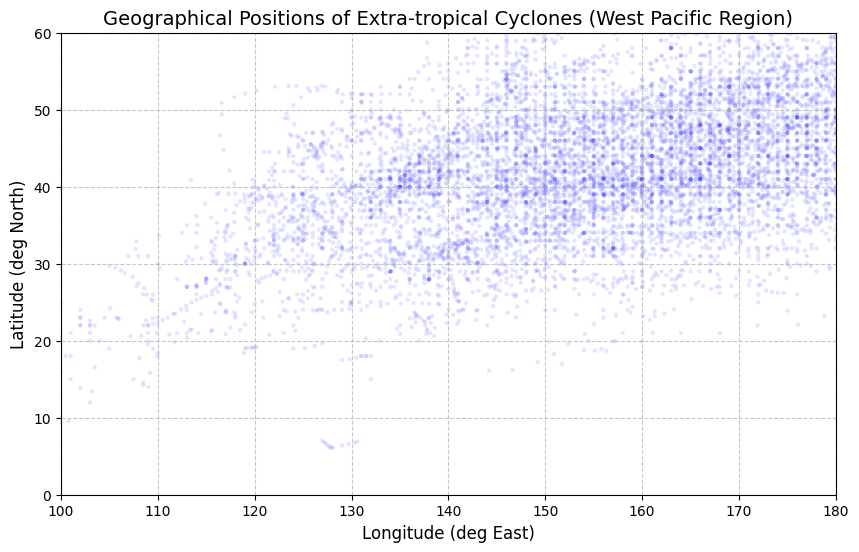

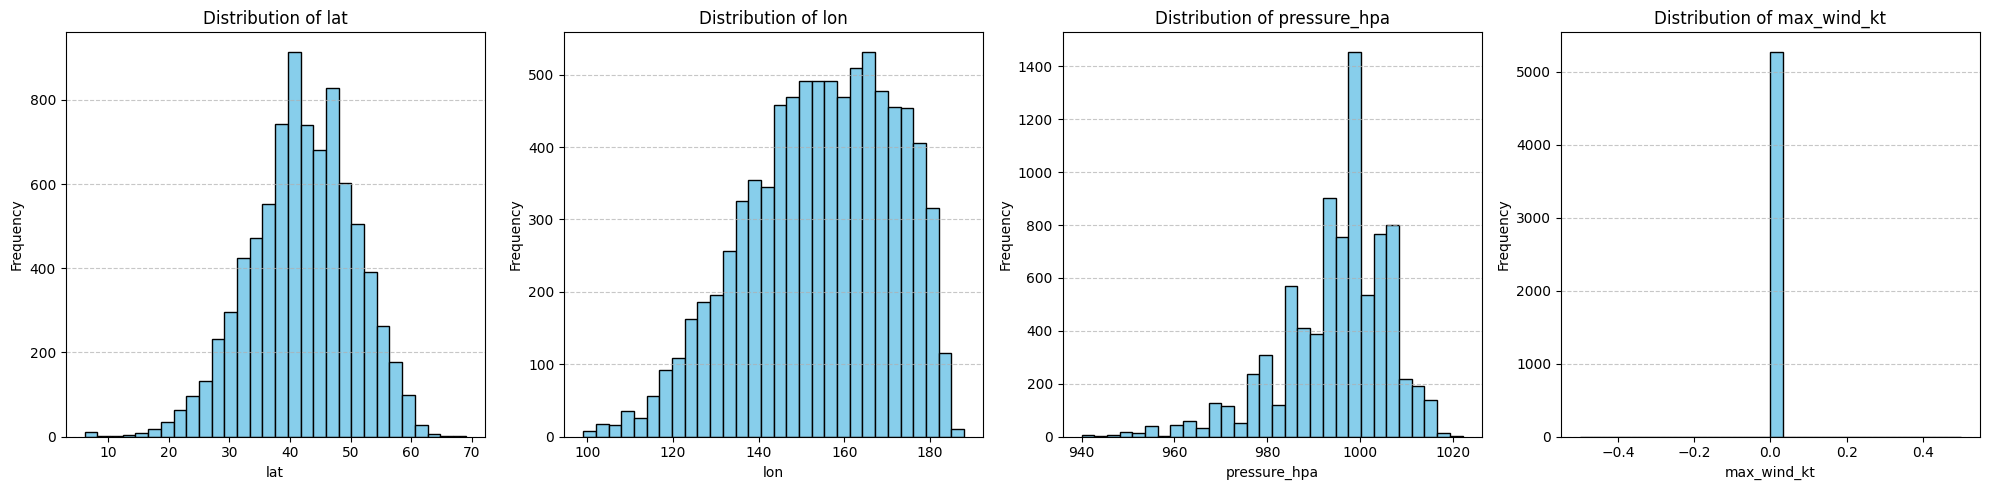

In [27]:
# Filter data for Extra-tropical Cyclones
extratropical = df[df['grade_name'] == 'Extra-tropical Cyclone (L)'].copy()

# 1. Plot geographical positions in the context of the Western North Pacific
plt.figure(figsize=(10, 6))
plt.scatter(extratropical['lon'], extratropical['lat'], alpha=0.1, s=10, c='blue', edgecolors='none')

# Set the bounding box for the RSMC Tokyo-Typhoon Center area of responsibility (Western Pacific)
# Longitude: 100 E to 180 E, Latitude: Equator (0) to 60 N
plt.xlim(100, 180)
plt.ylim(0, 60)

plt.title('Geographical Positions of Extra-tropical Cyclones (West Pacific Region)', fontsize=14)
plt.xlabel('Longitude (deg East)', fontsize=12)
plt.ylabel('Latitude (deg North)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Plot feature distributions
features_to_plot = ['lat', 'lon', 'pressure_hpa']
if not extratropical['max_wind_kt'].isna().all():
    features_to_plot.append('max_wind_kt')

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(5 * len(features_to_plot), 5))
for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    extratropical[feat].dropna().plot.hist(ax=ax, bins=30, edgecolor='black', color='skyblue')
    ax.set_title(f'Distribution of {feat}', fontsize=12)
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Dataset Features
Finding out what the features inside the dataset are.

In [ ]:
# Find out what the features inside the dataset are
print("Features in the dataset:")
print(df.columns.tolist())

## Wind Feature Distributions
Plotting the distribution of all wind related features, except for those that represent direction.

In [ ]:
# Plot the distribution of all wind related features, except for those that represent direction
wind_features = [col for col in df.columns if ('wind' in col.lower() or 'kt' in col.lower()) and 'dir' not in col.lower()]
print("Wind related features to plot:", wind_features)

for feature in wind_features:
    plt.figure(figsize=(8, 4))
    df[feature].plot(kind='hist', bins=50, title=f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()